# Face Emotion Recognition - FER-2013 (ViT)

Part 7: A Vision Transformer (ViT) that classifies a 48x48 face into one of 7 emotions (angry, disgust, fear, happy, neutral, sad, surprise).



### Imports & Configuration

In [1]:
import os
import time
import shutil
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from torch import device
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from datetime import datetime
from xml.parsers.expat import model

# System Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

# Get the absolute path of the current notebook directory (src)
notebook_dir = os.path.abspath('')

# Move one level up to get the project root directory
PROJECT_ROOT = os.path.dirname(notebook_dir)

# Define the paths dynamically based on the project root
DATA_DIR = os.path.join(PROJECT_ROOT, "data", "FER2013")
OUT_DIR = os.path.join(PROJECT_ROOT, "outputs")
TARGET_DIR = os.path.join(OUT_DIR, "vit_final_model")

# Create output directories if they don't exist
os.makedirs(OUT_DIR, exist_ok=True)
run_dir = os.path.join(OUT_DIR, datetime.now().strftime("%Y%m%d_%H%M%S"))
os.makedirs(run_dir, exist_ok=True)

BATCH_SIZE = 64
EPOCHS = 50
CLASSES = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
N_CLASSES = len(CLASSES)

print(f"Device: {DEVICE}")

c:\TN2\project\cv_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


### Data Handling 
The data split (stratified 10% split, seed=42). Data augmentation and Random Erasing are strictly applied only to the Training set.

In [2]:
def get_loaders(data_dir, batch_size):
    """Loads the dataset, performs a stratified split, and computes class weights."""
    print("Preparing Data...")
    
    # Transforms
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        transforms.RandomErasing(p=0.2)
    ])

    eval_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    full_train = datasets.ImageFolder(root=os.path.join(data_dir, 'train'), transform=train_transform)
    full_train_clean = datasets.ImageFolder(root=os.path.join(data_dir, 'train'), transform=eval_transform)
    test_set = datasets.ImageFolder(root=os.path.join(data_dir, 'test'), transform=eval_transform)

    # Stratified Split
    targets = np.array(full_train.targets)
    train_idx, val_idx = [], []
    for c in range(N_CLASSES):
        idx = np.where(targets == c)[0]
        np.random.shuffle(idx)
        cut = round(len(idx) * 0.1)
        val_idx += idx[:cut].tolist()
        train_idx += idx[cut:].tolist()

    # DataLoaders (num_workers=2 for reduced overhead on Windows)
    train_loader = DataLoader(Subset(full_train, train_idx), batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(Subset(full_train_clean, val_idx), batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # Class Weights
    counts = np.bincount(targets[train_idx], minlength=N_CLASSES)
    class_weights = torch.tensor(counts.sum() / (N_CLASSES * counts), dtype=torch.float32).to(DEVICE)

    print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_set)}")
    return train_loader, val_loader, test_loader, class_weights, test_set

# Execute data loading
train_loader, val_loader, test_loader, class_weights, test_set = get_loaders(DATA_DIR, BATCH_SIZE)

# Function to plot class distribution
def plot_class_distribution(dataset, classes):
    print("Calculating class distribution...")
    counts = np.zeros(len(classes), dtype=int)
    
    # Fast counting via indices
    for idx in dataset.indices:
        label = dataset.dataset.targets[idx]
        counts[label] += 1

    # Print counts to the terminal
    print("\n--- Image Counts per Class ---")
    for i, c in enumerate(classes):
        print(f"{c.capitalize()}: {counts[i]} images")
    print("------------------------------\n")
    
plot_class_distribution(train_loader.dataset, CLASSES)

Preparing Data...
Train: 25837 | Val: 2872 | Test: 7178
Calculating class distribution...

--- Image Counts per Class ---
Angry: 3595 images
Disgust: 392 images
Fear: 3687 images
Happy: 6493 images
Neutral: 4469 images
Sad: 4347 images
Surprise: 2854 images
------------------------------



### ViT Training
The main training loop utilizes **Mixed Precision (AMP)** for speed and **Gradient Clipping (1.0)** to prevent exploding gradients in the ViT architecture. Additionally, Early Stopping (patience=6) is applied to automatically save the best performing model.

In [3]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, run_dir, patience=6, scheduler=None):
    print(f"\n Starting training for {epochs} epochs (with Early Stopping, Patience={patience})...")
    
    # Dictionary to track metrics
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr_history': []}
    
    best_acc = 0.0
    epochs_no_improve = 0  
    best_model_path = os.path.join(run_dir, "best_model.pth")
    scaler = torch.amp.GradScaler('cuda')

    for epoch in range(epochs):
        t0 = time.time()
        
        # --- Training Phase ---
        model.train()
        running_loss = 0.0
        train_correct = 0 # Counter for correct predictions
        
        for images, labels in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            
            optimizer.zero_grad(set_to_none=True)
            
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            # Unscale first to accurately calculate the gradient magnitudes
            scaler.unscale_(optimizer) 
            # Clip the gradients to max_norm=1.0 to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            
            running_loss += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item() # Count correct predictions
            
        epoch_loss = running_loss / len(train_loader)
        train_acc = 100. * train_correct / len(train_loader.dataset) # Train Accuracy
        
        # --- Validation Phase ---
        model.eval()
        val_correct = 0
        val_running_loss = 0.0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)
                
                with torch.amp.autocast('cuda'):
                    outputs = model(images)
                    v_loss = criterion(outputs, labels)
                    
                val_running_loss += v_loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()
        
        val_acc = 100. * val_correct / len(val_loader.dataset)
        val_loss = val_running_loss / len(val_loader)
        
        # Record current Learning Rate
        current_lr = optimizer.param_groups[0]['lr']
        
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr_history'].append(current_lr)
        
        tag = ""
        if val_acc > best_acc:
            best_acc = val_acc
            epochs_no_improve = 0 
            torch.save(model.state_dict(), best_model_path)
            tag = "(New Best)"
        else:
            epochs_no_improve += 1
            tag = f" (No improvement: {epochs_no_improve}/{patience})"
            
        print(f"Epoch {epoch+1:2d}/{epochs} | LR: {current_lr:.1e} | Train Loss: {epoch_loss:.3f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.3f} | Val Acc: {val_acc:.2f}% | Time: {time.time() - t0:.0f}s {tag}")

        if scheduler:
            scheduler.step()

        if epochs_no_improve >= patience:
            print(f"\n Model stopped improving after {epoch+1} epochs. Early Stopping triggered!")
            break

    print(f"\n Training completed! Best Validation Acc was: {best_acc:.2f}%")
    return history, best_model_path

### Evaluation, Visualization & Explainability
Final metrics (Confusion Matrix, Learning Curves) are extracted, and incorrect predictions are saved for qualitative analysis. Simultaneously, through Forward Hooks, Attention Maps are visualized, "opening" the ViT black-box to reveal exactly where the model focuses its attention.

In [4]:
def evaluate_and_plot(model, test_loader, run_dir, history=None):
    """Evaluates the model on the Test Set and plots the performance metrics."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            preds = model(images.to(DEVICE))
            all_preds.extend(preds.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())

    test_acc = 100. * np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"\n Final Test Accuracy: {test_acc:.2f}%\n")
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

    # Plots
    if history:
        plt.figure(figsize=(18, 5)) # Wider canvas for 3 plots
        
        # 1. Confusion Matrix
        plt.subplot(1, 3, 1)
        cm = confusion_matrix(all_labels, all_preds)
        cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
        sns.heatmap(cm_norm, annot=cm, fmt='.2f', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
        plt.title("Confusion Matrix (Test Set)")
        plt.ylabel("True")
        plt.xlabel("Predicted")

        # 2. Loss Curve
        plt.subplot(1, 3, 2)
        plt.plot(history['train_loss'], label='Train Loss', marker='o', color='blue')
        plt.plot(history['val_loss'], label='Val Loss', marker='o', color='red')
        plt.title('Training & Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()

        # 3. Accuracy Curve
        plt.subplot(1, 3, 3)
        plt.plot(history['val_acc'], label='Val Acc', marker='o', color='green')
        plt.title('Validation Accuracy Progress')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy (%)')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
    else:
        plt.figure(figsize=(6, 5))
        cm = confusion_matrix(all_labels, all_preds)
        cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
        sns.heatmap(cm_norm, annot=cm, fmt='.2f', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
        plt.title("Confusion Matrix (Test Set)")
        plt.ylabel("True")
        plt.xlabel("Predicted")

    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "evaluation_plots.png"), dpi=120)
    plt.show()
    
    return all_preds, all_labels

def save_mistakes(test_set, all_preds, all_labels, run_dir):
    """Saves misclassified images into a dedicated directory for error analysis."""
    mis_dir = os.path.join(run_dir, "wrongly_classified")
    os.makedirs(mis_dir, exist_ok=True)
    test_paths = [path for path, _ in test_set.samples]
    
    saved_count = 0
    for i in range(len(test_paths)):
        true_label, pred_label = all_labels[i], all_preds[i]
        if true_label != pred_label:
            target_folder = os.path.join(mis_dir, f"{CLASSES[true_label]}_as_{CLASSES[pred_label]}")
            os.makedirs(target_folder, exist_ok=True)
            shutil.copy(test_paths[i], target_folder)
            saved_count += 1
            
    print(f"\nSaved {saved_count} misclassified images to: {mis_dir}")
    
def plot_prediction_grid(model, test_loader, classes, device, num_images=16):
    model.eval()
    
    # Fetch a single batch of data
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)
    
    with torch.no_grad():
        outputs = model(images)
        preds = outputs.argmax(1)
    
    # Reverse normalization (ImageNet stats) for proper visualization
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    
    fig, axes = plt.subplots(4, 4, figsize=(10, 12))
    fig.suptitle("Random Predictions (Test Set)", fontsize=16)
    
    for i, ax in enumerate(axes.flat):
        if i >= num_images or i >= len(images): break
        
        # Convert image back to (H, W, C) format for matplotlib
        img = inv_normalize(images[i]).cpu().permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        true_label = classes[labels[i].item()]
        pred_label = classes[preds[i].item()]
        color = 'green' if true_label == pred_label else 'red'
        
        ax.imshow(img)
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color)
        ax.axis('off')
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

def plot_attention_map(model, test_loader, classes, device):
    model.eval()
    images, labels = next(iter(test_loader))
    
    # Pick a random image from the batch (0 to batch_size-1)
    idx = np.random.randint(0, len(images))
    img_tensor = images[idx:idx+1].to(device) 
    true_label = classes[labels[idx].item()]
    
    attn_weights = []
    
    def qkv_hook(module, inp, out):
        B, N, C_out = out.shape
        attn_module = model.blocks[-1].attn
        num_heads = attn_module.num_heads
        head_dim = C_out // 3 // num_heads
        
        qkv = out.reshape(B, N, 3, num_heads, head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        
        q = q * attn_module.scale
        attn = q @ k.transpose(-2, -1)
        attn = attn.softmax(dim=-1)
        attn_weights.append(attn.detach().cpu())
    
    handle = model.blocks[-1].attn.qkv.register_forward_hook(qkv_hook)
    
    with torch.no_grad():
        output = model(img_tensor)
        pred_label = classes[output.argmax(1).item()]
        
    handle.remove()
    
    attn = attn_weights[0].mean(dim=1) 
    cls_attn = attn[0, 0, 1:].reshape(14, 14).numpy()
    
    # Attention Sink Suppression
    # Suppress the 4 extreme corners to prevent them from dominating the heatmap
    # We set them to the median attention value of the entire image.
    median_val = np.median(cls_attn)
    cls_attn[0, 0] = median_val   # Top-Left
    cls_attn[0, -1] = median_val  # Top-Right
    cls_attn[-1, 0] = median_val  # Bottom-Left
    cls_attn[-1, -1] = median_val # Bottom-Right    
    
    cls_attn = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min())
    cls_attn_resized = cv2.resize(cls_attn, (224, 224))
    
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    orig_img = inv_normalize(img_tensor[0]).cpu().permute(1, 2, 0).numpy()
    orig_img = np.clip(orig_img, 0, 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    axes[0].imshow(orig_img)
    axes[0].set_title(f"Original Image\nTrue: {true_label} | Pred: {pred_label}")
    axes[0].axis('off')
    
    axes[1].imshow(cls_attn_resized, cmap='jet')
    axes[1].set_title("Attention Map")
    axes[1].axis('off')
    
    axes[2].imshow(orig_img)
    axes[2].imshow(cls_attn_resized, cmap='jet', alpha=0.5)
    axes[2].set_title("Overlay")
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()

### Main Execution Pipeline
Defines the optimized architecture (Full Unfreezing, AdamW + Cosine Annealing, Label Smoothing) and automatically executes the training loop, evaluation metrics, and the extraction of 5 Attention Maps. The `TRAIN_MODE` flag dictates whether to train from scratch (~1 min/epoch on GPU) or load a pre-trained model for instant inference.

Preparing Data...
Train: 25837 | Val: 2872 | Test: 7178

[MODE: TRAINING] Starting training with 5.53 million parameters...

 Starting training for 50 epochs (with Early Stopping, Patience=6)...
Epoch  1/50 | LR: 1.0e-04 | Train Loss: 1.872 | Train Acc: 34.83% | Val Loss: 1.721 | Val Acc: 57.31% | Time: 71s (New Best)
Epoch  2/50 | LR: 1.0e-04 | Train Loss: 1.624 | Train Acc: 52.98% | Val Loss: 1.634 | Val Acc: 59.26% | Time: 71s (New Best)
Epoch  3/50 | LR: 1.0e-04 | Train Loss: 1.540 | Train Acc: 58.33% | Val Loss: 1.597 | Val Acc: 62.64% | Time: 73s (New Best)
Epoch  4/50 | LR: 9.9e-05 | Train Loss: 1.471 | Train Acc: 62.34% | Val Loss: 1.586 | Val Acc: 63.47% | Time: 74s (New Best)
Epoch  5/50 | LR: 9.8e-05 | Train Loss: 1.431 | Train Acc: 64.21% | Val Loss: 1.549 | Val Acc: 65.91% | Time: 70s (New Best)
Epoch  6/50 | LR: 9.8e-05 | Train Loss: 1.391 | Train Acc: 66.42% | Val Loss: 1.557 | Val Acc: 65.98% | Time: 71s (New Best)
Epoch  7/50 | LR: 9.6e-05 | Train Loss: 1.352 | Train A

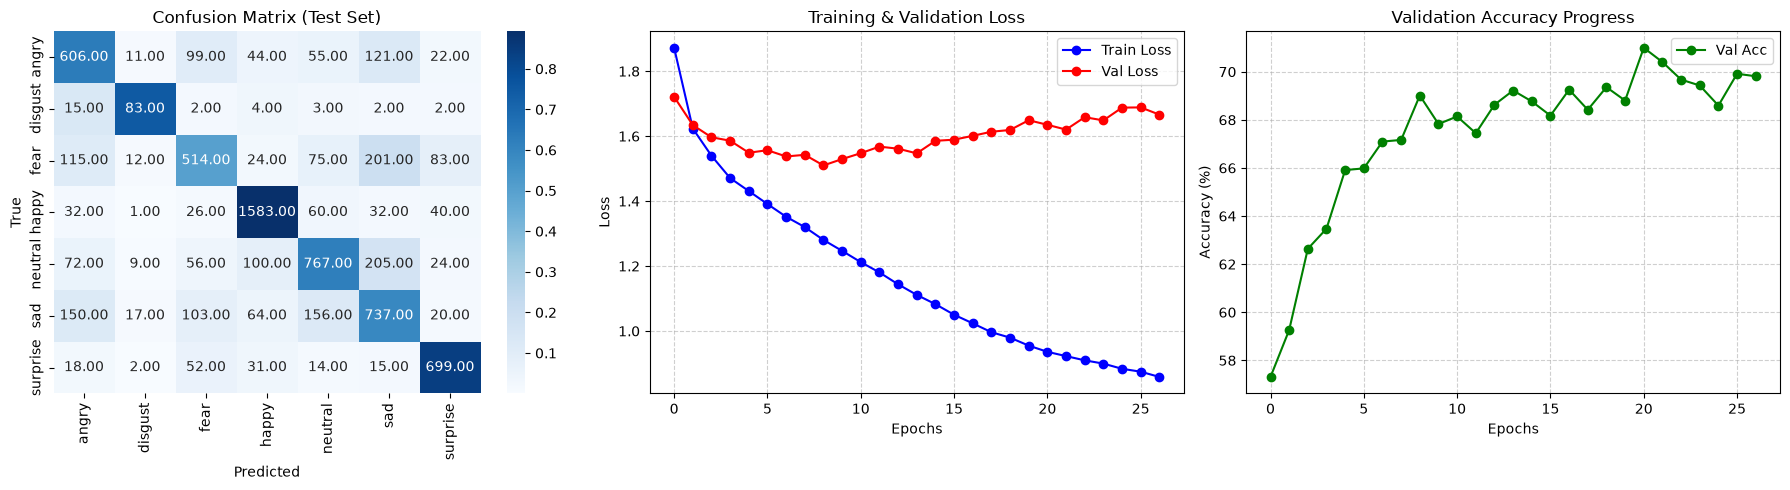


Saved 2189 misclassified images to: c:\TN2\project\outputs\vit_final_model\wrongly_classified

Printing Prediction Grid...


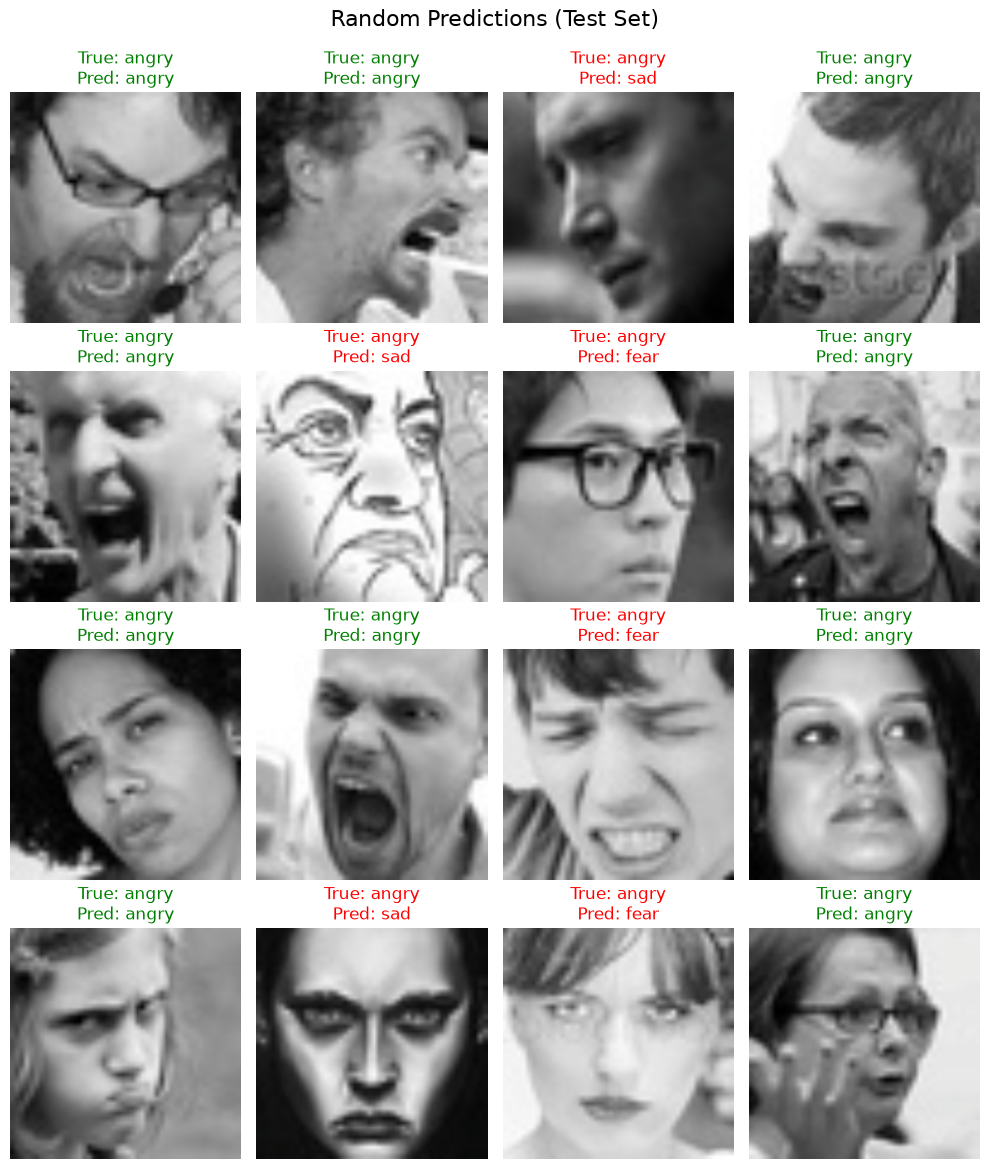


Printing 5 Attention Maps...


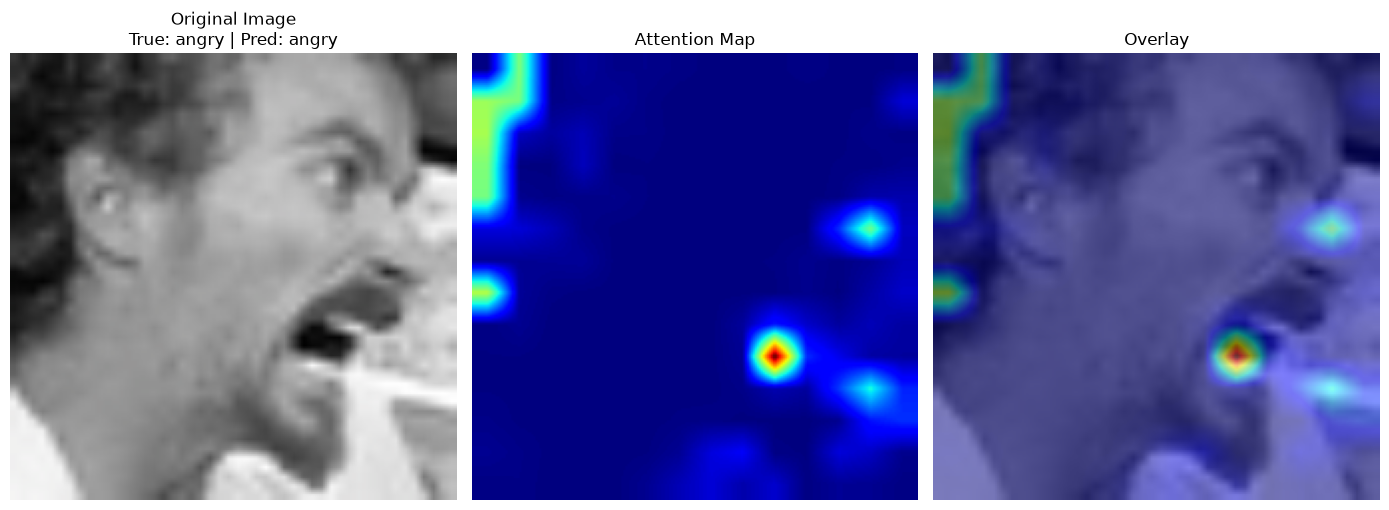

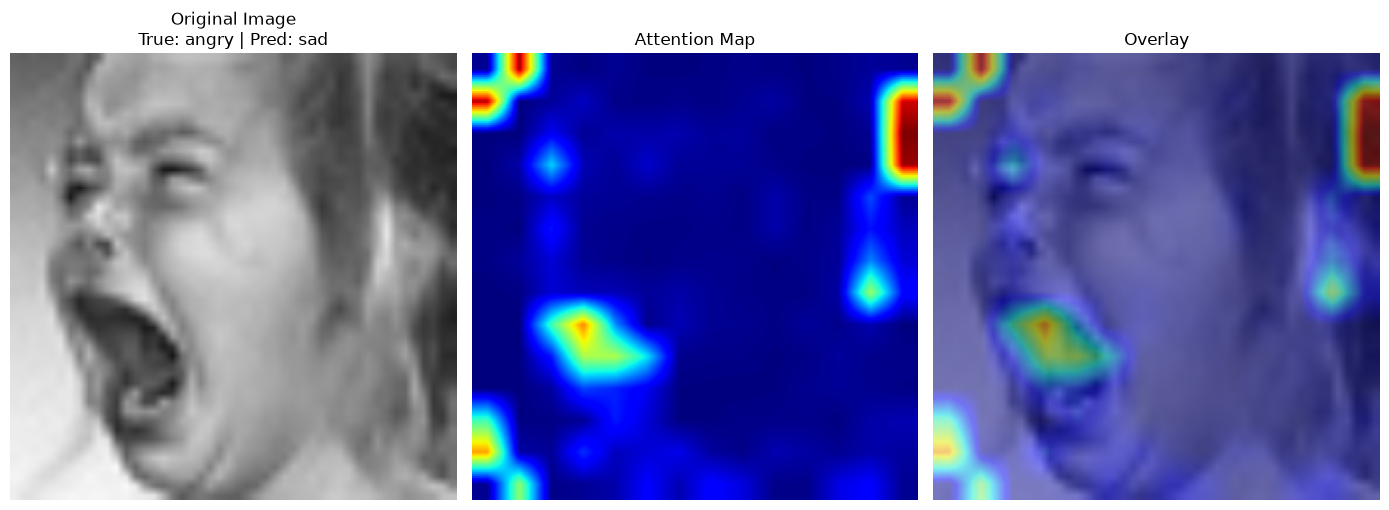

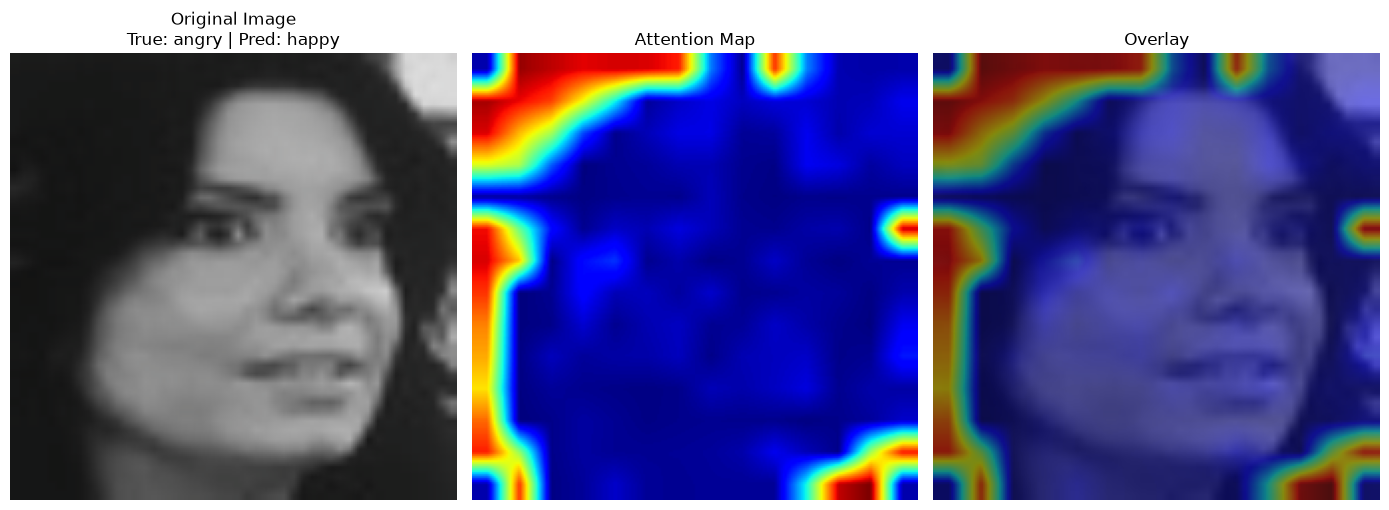

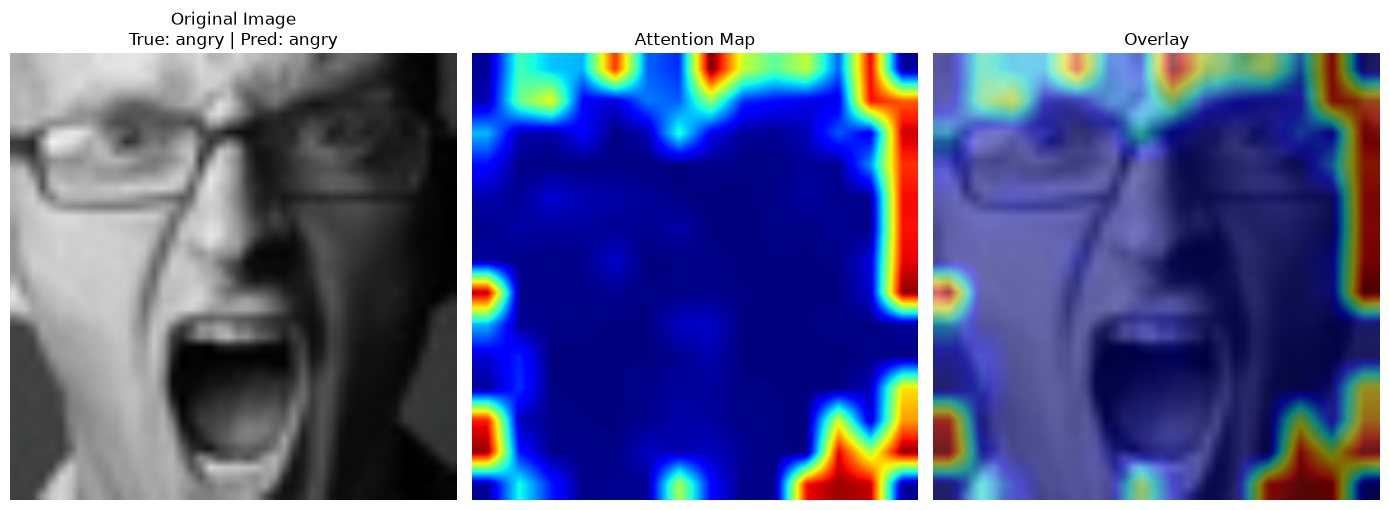

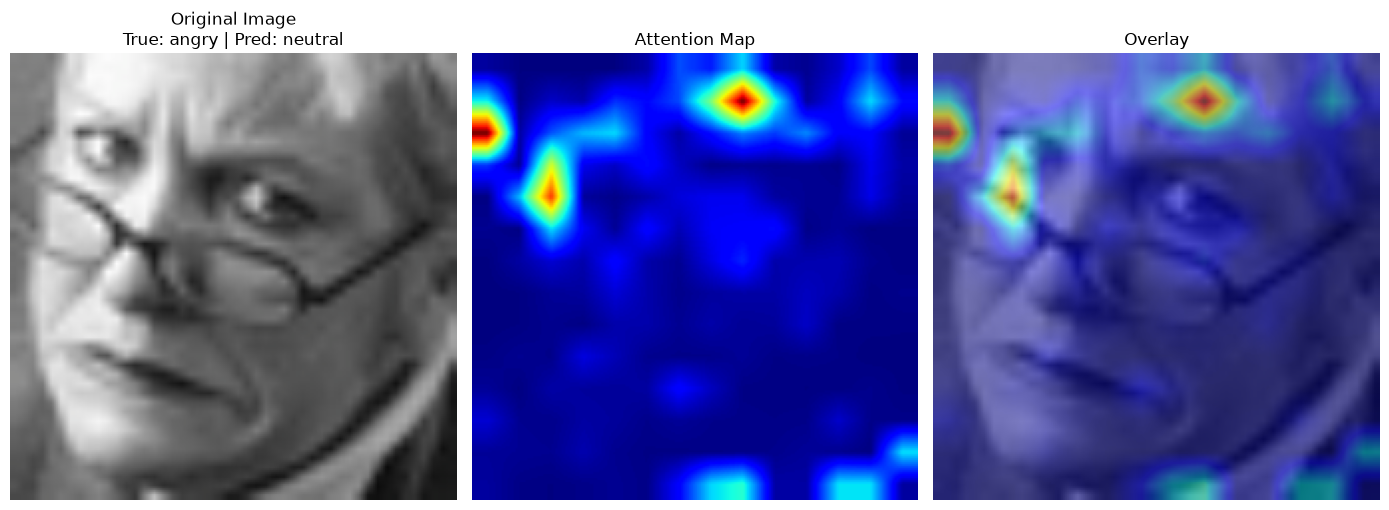


All results have been updated in directory: c:\TN2\project\outputs\vit_final_model


In [ ]:
# =============================================================================
# EXECUTION MODE FLAG & DIRECTORY SETTINGS
# =============================================================================
TRAIN_MODE = False  # True: Train from scratch | False: Load pre-trained model

# Uses the OUT_DIR variable we defined in the setup cell.
TARGET_DIR = os.path.join(OUT_DIR, "vit_final_model") 

# --- 1. Initialize Results Directory ---
os.makedirs(TARGET_DIR, exist_ok=True)
run_dir = TARGET_DIR

best_model_path = os.path.join(run_dir, "best_model.pth")
history_path = os.path.join(run_dir, "history.pt")

# --- 2. Load Data ---
train_loader, val_loader, test_loader, class_weights, test_set = get_loaders(DATA_DIR, BATCH_SIZE)

# --- 3. Initialize Vision Transformer Architecture ---
model = timm.create_model('vit_tiny_patch16_224', pretrained=TRAIN_MODE, num_classes=N_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# --- 4. Execution: Train or Load Weights ---
if TRAIN_MODE:
    for param in model.parameters():
        param.requires_grad = True
        
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    params_in_millions = trainable_params / 1_000_000
        
    print(f"\n[MODE: TRAINING] Starting training with {params_in_millions:.2f} million parameters...")
    # Training loop
    history, best_model_path = train_model(model, train_loader, val_loader, criterion, optimizer, EPOCHS, run_dir, patience=6, scheduler=scheduler)
    
    # Overwrite the history file
    torch.save(history, history_path)
    print("Training history saved successfully.")
    
else:
    print(f"\n[MODE: INFERENCE] Bypassing training. Loading weights from: {best_model_path}")
    model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    
    if os.path.exists(history_path):
        history = torch.load(history_path)
        print("Training history loaded for visualizations.")
    else:
        history = None
        print("Warning: Previous history not found. Only the Confusion Matrix will be displayed.")

# --- 5. Final Model Evaluation ---
print("\nRunning evaluation on the Test Set...")
all_preds, all_labels = evaluate_and_plot(model, test_loader, run_dir, history)

# --- 6. Extract Misclassifications ---
save_mistakes(test_set, all_preds, all_labels, run_dir)

# --- 7. Visualizations (Grid & Attention Maps) ---
print("\nPrinting Prediction Grid...")
plot_prediction_grid(model, test_loader, CLASSES, DEVICE)

print("\nPrinting 5 Attention Maps...")
for _ in range(5):
    plot_attention_map(model, test_loader, CLASSES, DEVICE)

print(f"\nAll results have been updated in directory: {run_dir}")